# AgriShield

End-to-end soil-risk pipeline: harmonise surveys, train a classifier, query live satellite and weather for a new site.

```
LUCAS + WoSIS  →  data/agrishield_training.csv  →  RandomForest
New lat/lon    →  GEE (NDVI, WorldClim) + OpenWeather  →  risk report
```

Logic lives in `agrishield/`. This notebook is the runbook, not a scratch pad.

## 1. Environment

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from agrishield.config import EXAMPLE_SITE, FEATURE_COLUMNS, TRAINING_CSV
from agrishield.dataset import load_training_table
from agrishield.inference import live_features
from agrishield.model import predict_proba, save_model, train

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 24)
print("root:", ROOT)
print("training table:", TRAINING_CSV, "exists=" + str(TRAINING_CSV.exists()))

root: d:\Jupyter Lab\Agrishield AI
training table: D:\Jupyter Lab\Agrishield AI\data\agrishield_training.csv exists=True


## 2. Training table

LUCAS 2018 (all chemistry columns + bulk density), LUCAS 2015 as extra rows where the same point exists in 2018 (2015 has no coordinates of its own), and every WoSIS topsoil property file except sites/profiles/layers/observations.

GEE WorldClim is attached later as **columns** (`tmean_c`, `precip_mm`) on these same rows. OpenWeather is not written into this file.

`rebuild=True` rebuilds the soil table from the raw surveys.

In [2]:
df = load_training_table(rebuild=True)
print("rows:", len(df), "cols:", df.shape[1])
print(df["source"].value_counts())
display(df.head())
print("missing % (head)")
print((df.isna().mean() * 100).round(1).sort_values().head(25))

rows: 232285 cols: 70
source
wosis         196509
lucas_2018     18983
lucas_2015     16793
Name: count, dtype: int64


,source,sample_id,latitude,longitude,country,continent,sample_year,ph_h2o,ph_cacl2,oc_gkg,oc_20_30_gkg,n_gkg,...,wosis_wg0100,wosis_wg0200,wosis_wg0500,wosis_wg1500,wosis_wv0010,wosis_wv0033,wosis_wv0100,wosis_wv0500,wosis_wv1500,acidic,low_oc,soil_stress
0,lucas_2018,47862690,47.150238,16.134212,AT,Europe,2018.0,4.81,4.1,12.4,NaN,1.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0
1,lucas_2018,47882704,47.274272,16.175359,AT,Europe,2018.0,4.93,4.1,16.7,NaN,1.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0
2,lucas_2018,47982688,47.123260,16.289693,AT,Europe,2018.0,4.85,4.1,47.5,NaN,3.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0
3,lucas_2018,48022702,47.245693,16.357506,AT,Europe,2018.0,5.80,5.5,28.1,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
4,lucas_2018,48062708,47.296372,16.416782,AT,Europe,2018.0,6.48,6.1,19.4,NaN,2.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0


missing % (head)
source          0.0
sample_id       0.0
latitude        0.0
longitude       0.0
country         0.0
continent       0.0
soil_stress     9.6
ph_h2o         25.4
acidic         25.4
oc_gkg         28.5
low_oc         28.5
clay_pct       32.9
silt_pct       37.2
sample_year    40.9
sand_pct       48.4
n_gkg          53.6
ph_cacl2       58.0
caco3          66.8
cec_ph7        75.5
wosis_cfvo     81.3
ec             82.7
nuts3          84.6
nuts1          84.6
nuts2          84.6
land_cover     84.6
dtype: float64


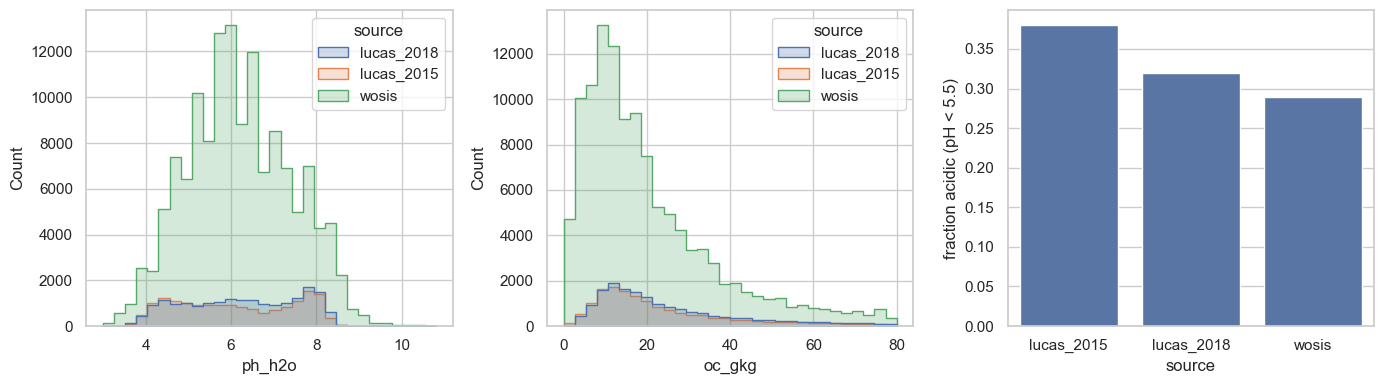

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(df, x="ph_h2o", hue="source", bins=30, ax=axes[0], element="step")
sns.histplot(df[df["oc_gkg"] < 80], x="oc_gkg", hue="source", bins=30, ax=axes[1], element="step")
sns.barplot(
    data=df.groupby("source")["acidic"].mean().reset_index(),
    x="source",
    y="acidic",
    ax=axes[2],
)
axes[2].set_ylabel("fraction acidic (pH < 5.5)")
plt.tight_layout()
plt.show()

## 2b. Climate columns from GEE (optional, slow)

WorldClim mean temperature and annual rainfall are sampled at each training lat/lon and stored as `tmean_c` and `precip_mm`. Same rows, extra columns.

Do **not** append OpenWeather here. Current weather is for inference only.

`max_rows=800` is a smoke test. `max_rows=None` fills the whole table (many GEE calls).

In [4]:
from agrishield.climate import enrich_training_csv

# Smoke test on the first 800 rows. Set max_rows=None overnight for the full table.
df = enrich_training_csv(batch_size=400, max_rows=800)
print("climate filled:", int(df["tmean_c"].notna().sum()), "/", len(df))
df[["latitude", "longitude", "ph_h2o", "tmean_c", "precip_mm"]].head()

climate filled: 800 / 232285


,latitude,longitude,ph_h2o,tmean_c,precip_mm
0,47.150238,16.134212,4.81,9.2,757
1,47.274272,16.175359,4.93,8.8,744
2,47.123260,16.289693,4.85,9.3,727
3,47.245693,16.357506,5.80,9.1,701
4,47.296372,16.416782,6.48,9.0,687


## 3. Model

Target: `acidic`. Features: OC, N, P, K, EC, carbonate, texture, elevation, bulk density, CEC, total carbon, and WorldClim if those columns are filled. pH is excluded from X.

In [5]:
model, report = train(df)
print(report)
path = save_model(model)
print("saved", path)
print("features", FEATURE_COLUMNS)

              precision    recall  f1-score   support

         0.0      0.817     0.909     0.861     24191
         1.0      0.715     0.527     0.607     10448

    accuracy                          0.794     34639
   macro avg      0.766     0.718     0.734     34639
weighted avg      0.786     0.794     0.784     34639

saved D:\Jupyter Lab\Agrishield AI\models\soil_risk_rf.joblib
features ['oc_gkg', 'n_gkg', 'p_mgkg', 'k_mgkg', 'ec', 'caco3', 'clay_pct', 'sand_pct', 'silt_pct', 'coarse_pct', 'elevation_m', 'bd_0_20', 'cec_ph7', 'totc_gkg', 'tmean_c', 'precip_mm']


## 4. Inference for a new site

GEE and OpenWeather are called here, not while fitting the forest. WorldClim is climatology at the point; Sentinel-2 and OpenWeather are current conditions.

Default site is Clayton, Victoria (`agrishield.config.EXAMPLE_SITE`). Change lat/lon to score another location.

Live APIs do not return lab pH/OC. The classifier still needs those soil features. Until SoilGrids (or a local sample) fills them, this section reports satellite/weather context plus a model score only if you pass chemistry.

In [6]:
site = EXAMPLE_SITE
live = live_features(site["latitude"], site["longitude"])
print(site["name"], site["latitude"], site["longitude"])
live

Clayton, Victoria -37.91 145.13


{'latitude': -37.91,
 'longitude': 145.13,
 'sentinel': {'B4': 303, 'B8': 2082, 'NDVI': 0.7459119558334351},
 'worldclim': {'tmean_c': 14.4, 'precip_mm': 836},
 'weather': {'temp_c': 7.95,
  'humidity': 86,
  'pressure': 1029,
  'wind_speed': 0.64,
  'rain_1h_mm': 0,
  'description': 'clear sky'}}

In [7]:
# Optional: score using nearest training row as a soil analogue (not a soil test).
nearest = df.assign(
    d=(df["latitude"] - site["latitude"]) ** 2 + (df["longitude"] - site["longitude"]) ** 2
).nsmallest(1, "d").iloc[0]

analogue = {col: nearest[col] for col in FEATURE_COLUMNS}
print("nearest survey analogue")
print(nearest[["source", "country", "ph_h2o", "oc_gkg", "n_gkg", "clay_pct"]])
print(predict_proba(model, analogue))

nearest survey analogue
source          wosis
country     Australia
ph_h2o            NaN
oc_gkg           90.0
n_gkg             4.8
clay_pct          NaN
Name: 71363, dtype: object
{'predicted': 1, 'probability': {0: 0.18, 1: 0.82}}
